# Lineage and impact analysis

`clair.lineage.get_dag()` gives the dependency graph of a project. The result is a
`ClairDag`, a subclass of the networkx `DiGraph` class:

- each node is a physical address, such as `example_2_database.refined.orders`
- each edge is a (dependency, dependent) pair
- `dag.get_trouve(name)` gives the compiled Trouve of that node

Thus each networkx algorithm applies to your warehouse. This notebook answers the four
questions that a data team asks each week:

1. What does this project hold?
2. What breaks if this source changes?
3. What must clair build before this table?
4. Which tables does nothing read?

The graph needs no warehouse connection.

In [1]:
from pathlib import Path


def find_examples_root(start: Path | None = None) -> Path:
    """Give the directory that holds examples/projects.

    The search starts at the working directory and it goes up. Thus the
    notebook runs from this directory, from the repository root, or from a
    Jupyter server that you started at a different place.
    """
    for directory in [start or Path.cwd(), *(start or Path.cwd()).parents]:
        if (directory / "examples" / "projects").is_dir():
            return directory
    raise FileNotFoundError("No parent directory holds examples/projects.")


REPOSITORY_ROOT = find_examples_root()

# The CLI configures structlog; a notebook does not. This line keeps the INFO
# messages of each operation out of the cells. Remove it to read them.
import logging

import structlog

structlog.configure(wrapper_class=structlog.make_filtering_bound_logger(logging.WARNING))

import os
from collections import defaultdict

import networkx as nx
import pandas as pd

from clair.lineage import get_dag

PROJECT = REPOSITORY_ROOT / "examples" / "projects" / "example_2"

# The routing entry of the dev environment reads CLAIR_USER.
os.environ["CLAIR_USER"] = "notebook_user"

dag = get_dag(PROJECT)
print(f"{dag.number_of_nodes()} nodes, {dag.number_of_edges()} edges")

52 nodes, 65 edges


## 1. What does this project hold?

The layer of a node is the length of the longest path to it. Thus layer 0 holds each root,
and a large layer number tells you that the Trouve waits for much work.

In [2]:
layer_of_node = {}
for node in nx.topological_sort(dag):
    parents = list(dag.predecessors(node))
    layer_of_node[node] = 0 if not parents else max(layer_of_node[parent] for parent in parents) + 1

inventory = pd.DataFrame(
    [
        {
            "layer": layer_of_node[node],
            "trouve": node.split(".", 1)[1],
            "type": dag.get_trouve(node).type.value,
            "reads": dag.in_degree(node),
            "read by": dag.out_degree(node),
            "tests": len(dag.get_trouve(node).tests or []),
        }
        for node in dag.nodes
    ]
).sort_values(["layer", "trouve"], ignore_index=True)

inventory

,layer,trouve,type,reads,read by,tests
0,0,reference.country_regions,table,0,1,0
1,0,source.events,source,0,1,0
2,0,source.inventory,source,0,1,0
3,0,source.order_items,source,0,1,0
4,0,source.orders,source,0,1,0
5,0,source.products,source,0,1,0
6,0,source.promotions,source,0,1,0
7,0,source.returns,source,0,1,0
8,0,source.reviews,source,0,1,0
9,0,source.sellers,source,0,1,0


## Draw the graph, top to bottom

Sources are grey, tables are blue, and views are green. Data flows down.

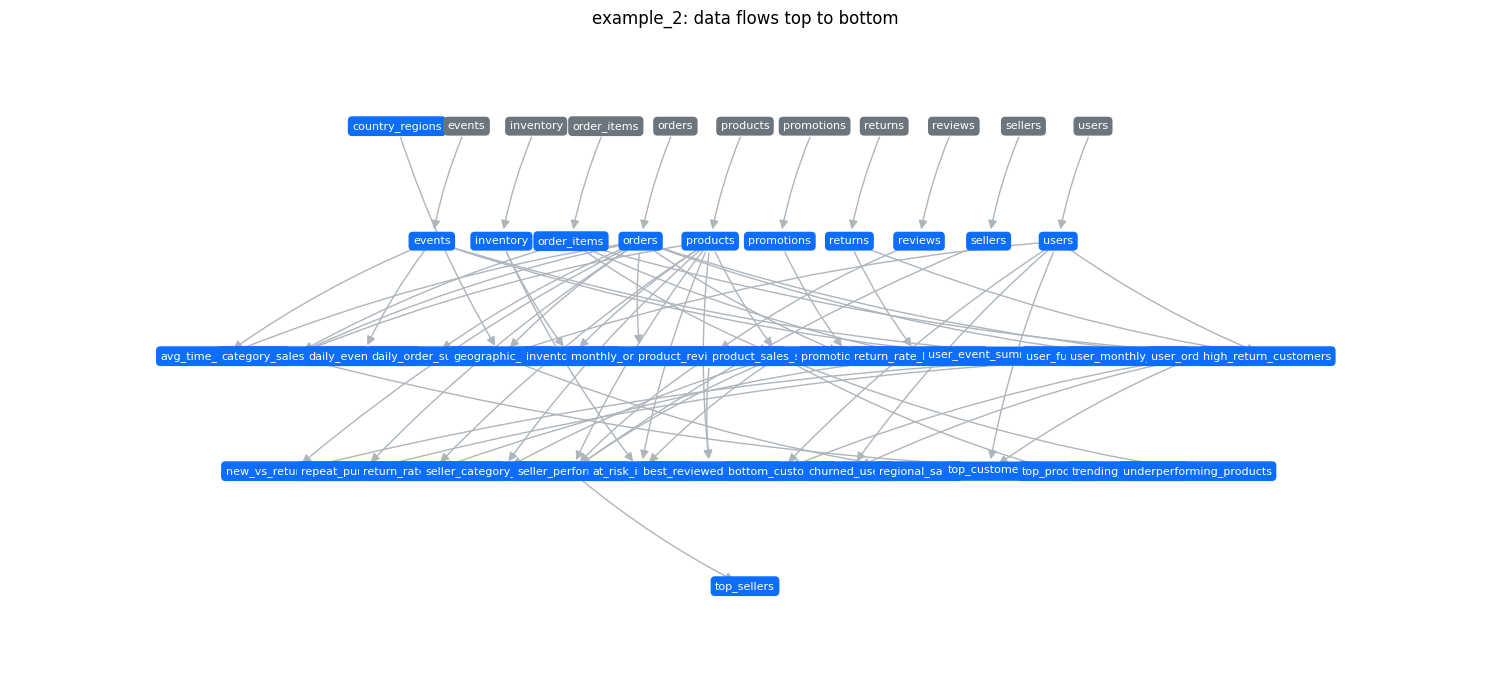

In [3]:
import matplotlib.pyplot as plt

COLOR_OF_TYPE = {"source": "#6c757d", "table": "#0d6efd", "view": "#198754"}


def layered_layout(graph, layer_of_node):
    """Give the position of each node. Layer 0 is at the top."""
    nodes_of_layer = defaultdict(list)
    for node in graph.nodes:
        nodes_of_layer[layer_of_node[node]].append(node)
    position_of_node = {}
    for layer, nodes in nodes_of_layer.items():
        nodes = sorted(nodes)
        for index, node in enumerate(nodes):
            position_of_node[node] = (index - (len(nodes) - 1) / 2, -layer)
    return position_of_node


def draw(graph, layer_of_node, title, figsize=(15, 7)):
    """Draw the graph with one row for each layer."""
    position_of_node = layered_layout(graph, layer_of_node)
    _, axes = plt.subplots(figsize=figsize)
    nx.draw_networkx_edges(
        graph,
        position_of_node,
        ax=axes,
        arrows=True,
        arrowsize=13,
        edge_color="#adb5bd",
        connectionstyle="arc3,rad=0.06",
    )
    for node, (x, y) in position_of_node.items():
        axes.text(
            x,
            y,
            node.split(".")[-1],
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            bbox={
                "boxstyle": "round,pad=0.4",
                "facecolor": COLOR_OF_TYPE[dag.get_trouve(node).type.value],
                "edgecolor": "none",
            },
            zorder=3,
        )
    axes.set_title(title)
    axes.margins(0.14)
    axes.axis("off")
    plt.tight_layout()
    plt.show()


draw(dag, layer_of_node, f"{PROJECT.name}: data flows top to bottom")

## 2. What breaks if this source changes?

`nx.descendants` gives each Trouve downstream of a node, at any distance. That set is the
impact of a schema change, and it is also the answer to "which tables hold data from this
source".

In [4]:
sources = [node for node in dag.nodes if dag.get_trouve(node).type.value == "source"]

pd.DataFrame(
    [
        {
            "source": node.split(".", 1)[1],
            "downstream count": len(nx.descendants(dag, node)),
            "direct children": dag.out_degree(node),
        }
        for node in sources
    ]
).sort_values("downstream count", ascending=False, ignore_index=True)

,source,downstream count,direct children
0,source.orders,16,1
1,source.order_items,13,1
2,source.products,13,1
3,source.users,7,1
4,source.reviews,5,1
5,source.events,5,1
6,source.returns,4,1
7,source.inventory,3,1
8,source.sellers,3,1
9,source.promotions,2,1


In [5]:
# The complete blast radius of the source with the largest impact, in build order.
largest_source = max(sources, key=lambda node: len(nx.descendants(dag, node)))
downstream = nx.descendants(dag, largest_source)

print(f"A change to {largest_source} reaches {len(downstream)} Trouves:")
for node in nx.topological_sort(dag.subgraph(downstream)):
    print(f"  layer {layer_of_node[node]}  {node}")

A change to example_2_database.source.orders reaches 16 Trouves:
  layer 1  example_2_database.refined.orders
  layer 2  example_2_database.derived.avg_time_to_purchase
  layer 2  example_2_database.derived.category_sales_summary
  layer 2  example_2_database.derived.daily_order_summary
  layer 2  example_2_database.derived.geographic_sales
  layer 2  example_2_database.derived.monthly_order_summary
  layer 2  example_2_database.derived.promotion_usage
  layer 2  example_2_database.derived.user_monthly_spend
  layer 2  example_2_database.derived.user_order_stats
  layer 3  example_2_database.reports.trending_categories
  layer 3  example_2_database.reports.regional_sales
  layer 3  example_2_database.derived.new_vs_returning_users
  layer 3  example_2_database.derived.repeat_purchase_rate
  layer 3  example_2_database.reports.bottom_customers
  layer 3  example_2_database.reports.churned_users
  layer 3  example_2_database.reports.top_customers


The equivalent command is `clair run --select '<address>+'`. The notebook adds the count,
the layer, and a drawing.

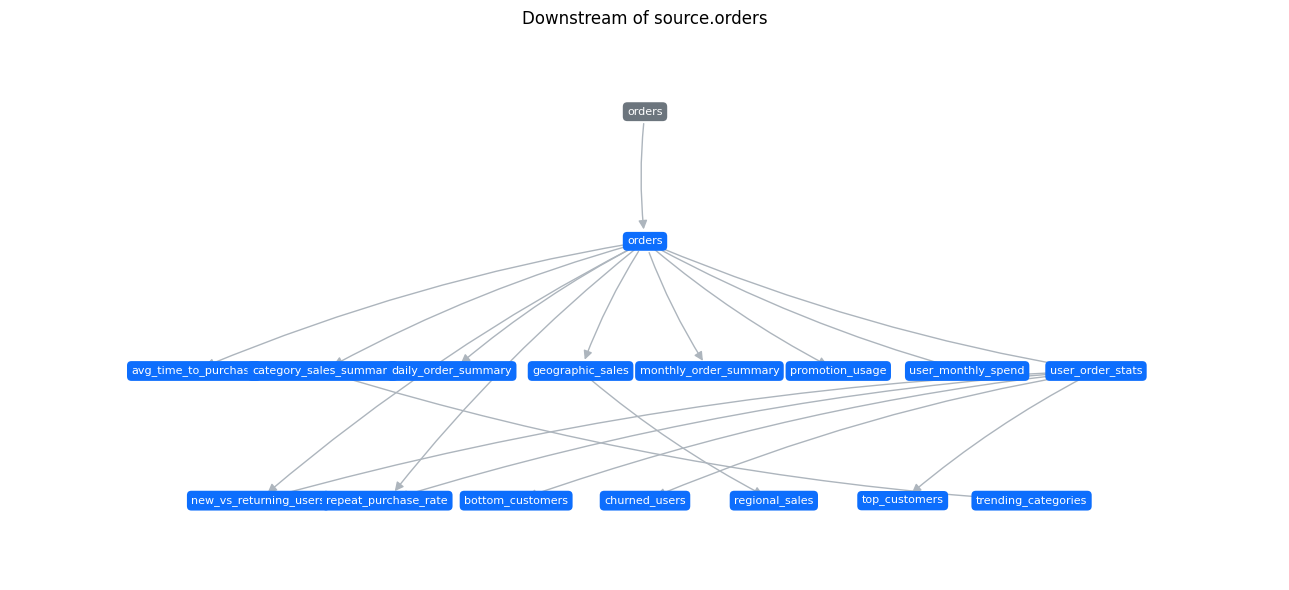

In [6]:
draw(
    dag.subgraph(downstream | {largest_source}),
    layer_of_node,
    f"Downstream of {largest_source.split('.', 1)[1]}",
    figsize=(13, 6),
)

## 3. What must clair build before this table?

`nx.ancestors` gives each Trouve upstream. This is the equivalent of
`clair run --select '+<address>'`. It answers "what does this report depend on", and the
topological order gives the build order.

In [7]:
target = max(dag.nodes, key=lambda node: len(nx.ancestors(dag, node)))
upstream = nx.ancestors(dag, target)

print(f"{target} needs {len(upstream)} Trouves:")
for index, node in enumerate(nx.topological_sort(dag.subgraph(upstream | {target})), start=1):
    marker = "->" if node == target else "  "
    print(f" {marker} {index:>2}. {node}")

example_2_database.reports.top_sellers needs 11 Trouves:
     1. example_2_database.source.products
     2. example_2_database.source.sellers
     3. example_2_database.source.order_items
     4. example_2_database.source.reviews
     5. example_2_database.refined.products
     6. example_2_database.refined.sellers
     7. example_2_database.refined.order_items
     8. example_2_database.refined.reviews
     9. example_2_database.derived.product_sales_summary
    10. example_2_database.derived.product_review_summary
    11. example_2_database.derived.seller_performance
 -> 12. example_2_database.reports.top_sellers


### The chain that decides the time of a run

The longest path holds the Trouves that wait for each other. clair runs the other branches
in parallel, thus this chain gives the smallest possible time of a full refresh.

In [8]:
longest_chain = nx.dag_longest_path(dag)
print(f"{len(longest_chain)} Trouves in the longest chain:")
for node in longest_chain:
    print(f"  -> {node.split('.', 1)[1]}")

5 Trouves in the longest chain:
  -> source.order_items
  -> refined.order_items
  -> derived.product_sales_summary
  -> derived.seller_performance
  -> reports.top_sellers


### How much work runs in parallel?

Each generation of the topological sort is a group that clair can build at one time. The
size of the largest generation tells you how many threads the project uses.

In [9]:
generations = list(nx.topological_generations(dag))
print(f"{len(generations)} generations. Give clair {max(len(group) for group in generations)} threads.")

for index, group in enumerate(generations):
    names = sorted(node.split(".", 1)[1] for node in group)
    print(f"  {index}: {len(group):>2} Trouves  {names}")

5 generations. Give clair 16 threads.
  0: 11 Trouves  ['reference.country_regions', 'source.events', 'source.inventory', 'source.order_items', 'source.orders', 'source.products', 'source.promotions', 'source.returns', 'source.reviews', 'source.sellers', 'source.users']
  1: 10 Trouves  ['refined.events', 'refined.inventory', 'refined.order_items', 'refined.orders', 'refined.products', 'refined.promotions', 'refined.returns', 'refined.reviews', 'refined.sellers', 'refined.users']
  2: 16 Trouves  ['derived.avg_time_to_purchase', 'derived.category_sales_summary', 'derived.daily_event_counts', 'derived.daily_order_summary', 'derived.geographic_sales', 'derived.inventory_alerts', 'derived.monthly_order_summary', 'derived.product_review_summary', 'derived.product_sales_summary', 'derived.promotion_usage', 'derived.return_rate_by_product', 'derived.user_event_summary', 'derived.user_funnel', 'derived.user_monthly_spend', 'derived.user_order_stats', 'reports.high_return_customers']
  3: 14 T

## 4. Which tables does nothing read?

A node with no child is a leaf: a report, or a table that nobody uses. A leaf with no test
and no docs is a good target for the next review.

In [10]:
leaves = [
    node
    for node in dag.nodes
    if dag.out_degree(node) == 0 and dag.get_trouve(node).type.value != "source"
]

pd.DataFrame(
    [
        {
            "leaf": node.split(".", 1)[1],
            "layer": layer_of_node[node],
            "tests": len(dag.get_trouve(node).tests or []),
            "has docs": bool((dag.get_trouve(node).docs or "").strip()),
        }
        for node in sorted(leaves)
    ]
)

,leaf,layer,tests,has docs
0,derived.avg_time_to_purchase,2,0,True
1,derived.daily_event_counts,2,0,True
2,derived.daily_order_summary,2,0,True
3,derived.inventory_alerts,2,0,True
4,derived.monthly_order_summary,2,0,True
5,derived.new_vs_returning_users,3,0,True
6,derived.promotion_usage,2,0,True
7,derived.repeat_purchase_rate,3,0,True
8,derived.return_rate_by_category,3,0,True
9,derived.seller_category_breakdown,3,0,True


### Read the SQL of a node

The Trouve on each node holds the compiled SQL. Thus you can search the complete project
for a pattern: a hard-coded date, a `select *`, or a table that a person wrote as text.

In [11]:
nodes_with_select_star = [
    node
    for node in dag.nodes
    if dag.get_trouve(node).type.value != "source"
    and dag.get_trouve(node).compiled is not None
    and "select *" in (dag.get_trouve(node).compiled.resolved_sql or "").lower()
]
print(f"{len(nodes_with_select_star)} Trouves hold a 'select *':", nodes_with_select_star)

example = dag.get_trouve(longest_chain[-1])
print(f"\n--- {longest_chain[-1]} ---")
print(example.compiled.resolved_sql.strip()[:600])

0 Trouves hold a 'select *': []

--- example_2_database.reports.top_sellers ---
with p90 as (
            select percentile_cont(0.9) within group (order by total_revenue) as threshold
            from example_2_database.derived.seller_performance
        )
        select
            sp.seller_id,
            sp.seller_name,
            sp.is_verified,
            sp.product_count,
            sp.total_units_sold,
            sp.total_revenue,
            sp.avg_product_rating
        from example_2_database.derived.seller_performance sp
        cross join p90
        where sp.total_revenue >= p90.threshold
        order by sp.total_revenue desc


## An interactive graph

`pyvis` writes an HTML file that you can drag and zoom. It comes with the `examples`
extra. Hover a node to read its address and its docs.

In [12]:
from IPython.display import IFrame
from pyvis.network import Network

network = Network(directed=True, height="560px", width="100%", cdn_resources="remote")
network.set_options("""
{
  "layout": {
    "hierarchical": {
      "enabled": true,
      "direction": "UD",
      "sortMethod": "directed",
      "levelSeparation": 110,
      "nodeSpacing": 150
    }
  },
  "physics": { "enabled": false },
  "edges": { "arrows": { "to": { "enabled": true } } }
}
""")

for node in dag.nodes:
    trouve = dag.get_trouve(node)
    network.add_node(
        node,
        label=node.split(".")[-1],
        title=f"{node}\n\n{(trouve.docs or '').strip()[:200]}",
        color=COLOR_OF_TYPE[trouve.type.value],
    )
for parent, child in dag.edges:
    network.add_edge(parent, child)

network.write_html("dag.html", notebook=False)
IFrame("dag.html", width="100%", height="580px")

`dag.html` stays in this directory, and git does not track it. `clair docs` gives the same
graph with a search box, a column list, and the SQL of each Trouve.

## Next

- [03_run_without_snowflake.ipynb](03_run_without_snowflake.ipynb) — run a complete
  project against an adapter that you write.
- [04_author_trouves.ipynb](04_author_trouves.ipynb) — write a project in the notebook,
  and test a pandas transform with no warehouse.